#### importando as bibliotecas:

In [77]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib as plt

#### Para exibir os valores sem notacao cientifica:

In [78]:
pd.options.display.float_format="{:.2f}".format

#### trazendo o dataset do projeto

In [79]:
vendas = pd.read_csv('vendas_supermercado_com_cliente.csv',parse_dates=['Data'])

#### observando as primeiras linhas para entender o dataset

In [80]:
vendas.head()

,Data,Produto,Categoria,Preço,Quantidade,Desconto,Total_Venda,Idade,Renda
0,2023-01-01,Maçãs,Alimentos Frescos,16.46,10,0.00,164.60,49,2715.61
1,2023-01-01,Bananas,Alimentos Frescos,2.39,4,0.00,9.56,29,2280.15
2,2023-01-01,Laranjas,Alimentos Frescos,8.38,5,0.00,41.90,67,4419.56
3,2023-01-01,Tomates,Alimentos Frescos,2.03,15,0.00,30.45,29,3809.17
4,2023-01-01,Alface,Alimentos Frescos,37.14,14,0.00,519.96,24,1013.42


#### verificando os formatos das colunas e se há valores nulos

In [81]:
vendas.info()

<class 'pandas.DataFrame'>
RangeIndex: 20075 entries, 0 to 20074
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Data         20075 non-null  datetime64[us]
 1   Produto      20075 non-null  str           
 2   Categoria    20075 non-null  str           
 3   Preço        20075 non-null  float64       
 4   Quantidade   20075 non-null  int64         
 5   Desconto     20075 non-null  float64       
 6   Total_Venda  20075 non-null  float64       
 7   Idade        20075 non-null  int64         
 8   Renda        20075 non-null  float64       
dtypes: datetime64[us](1), float64(4), int64(2), str(2)
memory usage: 1.4 MB


Verificamos aqui que o dataset não tem nenhum valor nulo

#### Verificando as principais medidas estatísticas

In [185]:
colunas_numericas = ['Preço', 'Quantidade', 'Desconto', 'Total_Venda', 'Idade', 'Renda']

In [191]:
resumo = vendas[colunas_numericas].agg([
    'mean',
    'median',
    'std',
    'var'
])

resumo.loc['moda'] = vendas[colunas_numericas].mode().iloc[0]

resumo.loc['amplitude'] = (
    vendas[colunas_numericas].max()
    - vendas[colunas_numericas].min()
)

resumo

,Preço,Quantidade,Desconto,Total_Venda,Idade,Renda
mean,25.58,10.01,0.04,245.90,45.99,2999.03
median,25.66,10.00,0.00,186.32,46.00,2998.83
std,14.12,5.49,0.09,207.77,16.48,1159.72
var,199.26,30.12,0.01,43169.91,271.66,1344944.39
moda,10.58,6.00,0.00,50.04,52.00,1630.87
amplitude,48.99,18.00,0.50,948.14,56.00,3999.38


#### criando uma coluna com o mês a partir da data

In [83]:
vendas['mes'] = vendas['Data'].dt.month_name(locale='pt_BR')

In [84]:
vendas.head(1)

,Data,Produto,Categoria,Preço,Quantidade,Desconto,Total_Venda,Idade,Renda,mes
0,2023-01-01,Maçãs,Alimentos Frescos,16.46,10,0.00,164.60,49,2715.61,Janeiro


analisando as primeiras estatisticas, vemos que o dataset tem dados compreendidos de 01/01/2023 até 31/12/2023 e não parecem ter dados muito fora do padrão, como descontos muito altos, valores unitarios muito grande

## 1. Quais foram as categorias produtos mais vendidos e em quais meses eles tiveram o maior pico de vendas?

In [85]:
vendas.groupby('Categoria')['Total_Venda'].sum().sort_values(ascending=False).head(3)

Categoria
Alimentos Frescos       1365309.46
Produtos de Mercearia    529653.65
Laticínios e Ovos        459960.47
Name: Total_Venda, dtype: float64

Verificamos através do groupby que as categorias mais vendidas são: <br>
1. Alimentos Frescos
2. Produtos de Mercearia
3. Laticínios e Ovos


In [86]:
mascara = (
vendas['Categoria'] == 'Alimentos Frescos') | (vendas['Categoria'] == 'Produtos de Mercearia') | (vendas['Categoria'] == 'Laticínios e Ovos'
)

mais_vendidos = vendas[mascara]



In [87]:
mais_vendidos = mais_vendidos.pivot_table(index='mes', columns='Categoria', values='Total_Venda', aggfunc='sum')

In [88]:
meses_ordenados = ['Janeiro', 'Fevereiro', 'Março', 'Abril', 'Maio', 'Junho', 'Julho', 'Agosto', 'Setembro', 'Outubro', 'Novembro', 'Dezembro']

mais_vendidos = mais_vendidos.reindex(meses_ordenados)

In [89]:
mais_vendidos 

Categoria,Alimentos Frescos,Laticínios e Ovos,Produtos de Mercearia
mes,,,
Janeiro,116281.50,39320.59,48079.73
Fevereiro,109234.29,36125.80,41780.88
Março,129103.45,42250.67,42370.61
Abril,98847.67,35310.61,46105.61
Maio,103923.98,34788.62,38992.32
Junho,120631.54,36898.82,43958.58
Julho,126769.38,37954.22,44296.37
Agosto,114280.75,37670.11,44156.45
Setembro,112849.47,40843.63,48192.29


<Axes: title={'center': 'Categorias mais vendidas'}, xlabel='Mês', ylabel='Total de Vendas'>

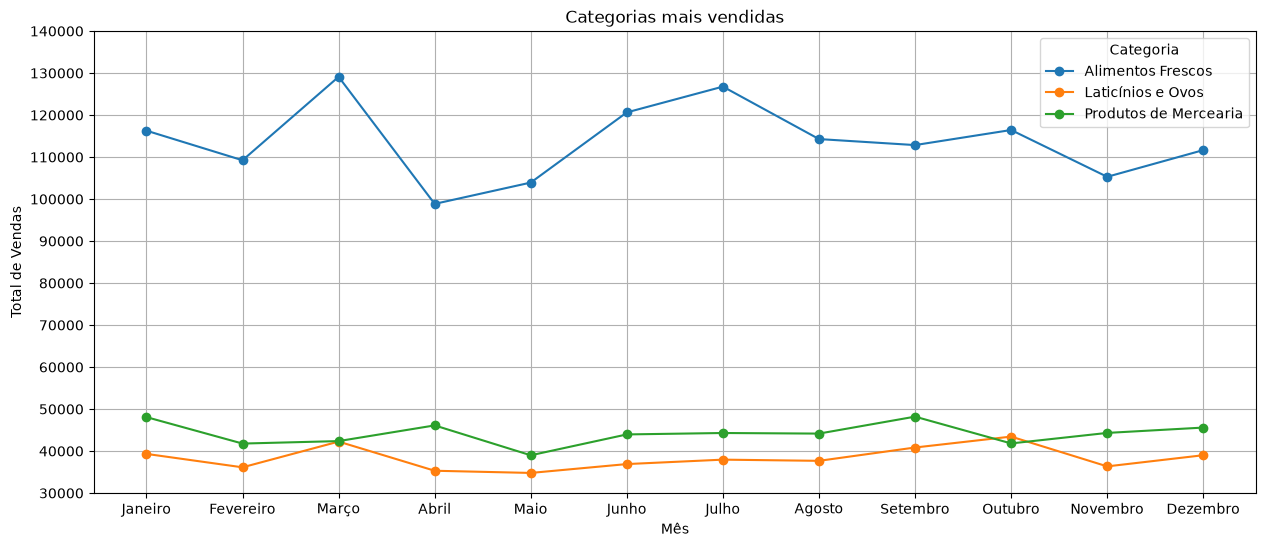

In [90]:
mais_vendidos.plot(figsize=(15, 6), kind='line', title='Categorias mais vendidas', ylabel='Total de Vendas', xlabel='Mês', marker='o', grid=True, legend=True, xticks=range(len(mais_vendidos.index)), yticks=range(30000, 145000, 10000))

O maior pico de vendas para Alimentos Frescos foi em Março e Julho<br>
Para os produtos de Mercearia foi em Janeiro, abril e Setembro <br>
E para os laticícios foi em Março e Outubro


## 2. Qual foi o impacto das promoções (descontos aplicados) nas vendas? Quais os produtos tiveram o maior aumento nas vendas durante as promoções

## 3. Qual a média de vendas diárias por categoria de produto?

In [91]:
vendas.groupby('Categoria')['Total_Venda'].mean()

Categoria
Alimentos Frescos             249.37
Bebidas                       248.98
Congelados                    240.94
Laticínios e Ovos             252.03
Pet Shop                      241.28
Produtos de Higiene Pessoal   241.12
Produtos de Limpeza           245.23
Produtos de Mercearia         241.85
Utilidades Domésticas         246.25
Name: Total_Venda, dtype: float64

## 4. Quais produtos apresentam a maior sazonalidade nas vendas?
### a. Para responder essa pergunta considere a medida de sazonalidade dada pelo coeficiente de variação mensal dos produtos

## 5. Quais as faixas etárias contribuíram mais para as vendas totais?
### Para responder essa pergunta, crie uma coluna com a faixa etária, considerando: entre 18 e 35 (jovem), entre 36 e 59 (adulto) e acima de 60 anos (idoso)

In [92]:
vendas['faixa etaria'] = pd.cut(vendas['Idade'], bins=[17, 36, 60, 100], labels=['jovem', 'adulto', 'idoso'])

In [93]:
vendas['faixa etaria'].info()

<class 'pandas.Series'>
RangeIndex: 20075 entries, 0 to 20074
Series name: faixa etaria
Non-Null Count  Dtype   
--------------  -----   
20075 non-null  category
dtypes: category(1)
memory usage: 19.9 KB


In [94]:
vendas.groupby('faixa etaria')['Total_Venda'].sum().sort_values(ascending=False)

faixa etaria
adulto   2116037.38
jovem    1617535.76
idoso    1202904.21
Name: Total_Venda, dtype: float64

A faixa etária que mais contribuiu com as vendas foram os adultos.

## 6. Qual a distribuição das vendas ao longo dos dias da semana?

In [95]:
vendas['dias_semana'] = vendas['Data'].dt.day_name(locale='pt_BR')

In [96]:
vendas_dia = vendas.groupby('dias_semana')['Total_Venda'].mean().sort_values(ascending=False)

In [97]:
ordem_dias = ['Segunda-feira', 'Terça-feira', 'Quarta-feira', 'Quinta-feira', 'Sexta-feira', 'Sábado', 'Domingo']

In [98]:
vendas_dia = vendas_dia.reindex(ordem_dias)

<Axes: title={'center': 'Média de vendas por dia da semana'}, xlabel='Total de Vendas', ylabel='Dia da Semana'>

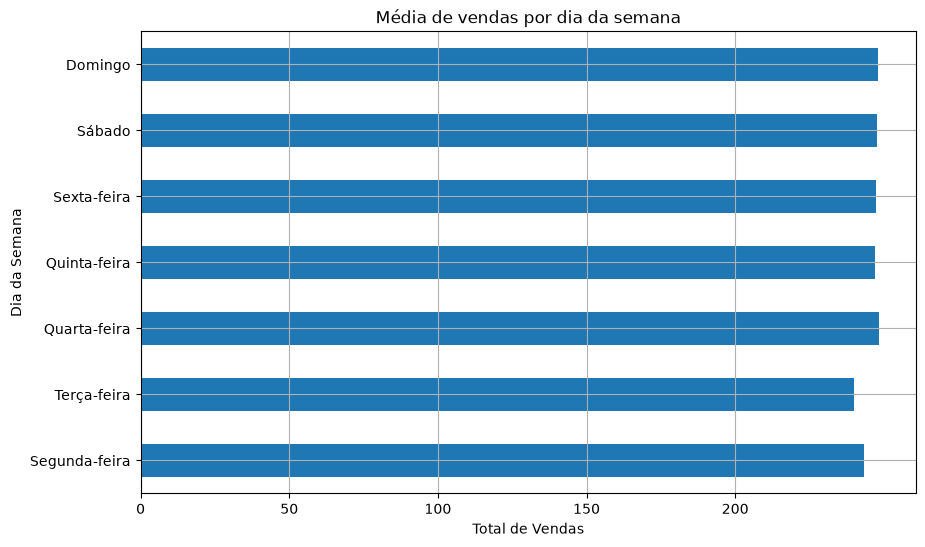

In [99]:
vendas_dia.plot(figsize=(10, 6), kind='barh', title='Média de vendas por dia da semana', ylabel='Dia da Semana', xlabel='Total de Vendas', grid=True, xticks=range(0, 250, 50))

a distribuiçao entre os dias de semana 

## 7. Como as vendas mensais se comparam antes e durante a Black Friday?

Em 2023 (ano no dataset) a black friday foi no dia 24/11/2023

In [154]:
vendas_black_semana = vendas[(vendas['Data'] < '2023-11-25') & (vendas['Data'] > '2023-11-18')]
vendas_fora_black = vendas[(vendas['Data'] < '2023-11-18') | (vendas['Data'] > '2023-11-25')]

In [155]:
Media_black = vendas_black_semana['Total_Venda'].mean()
Media_fora_black = vendas_fora_black['Total_Venda'].mean()

print(f'Média de vendas durante a semana da Black Friday: {Media_black:.2f}')
print(f'Média de vendas fora da semana da Black Friday: {Media_fora_black:.2f}')


Média de vendas durante a semana da Black Friday: 219.05
Média de vendas fora da semana da Black Friday: 246.67


In [102]:
vendas['Total_Venda'].mean()

np.float64(245.90173583561645)

De acordo com a média de vendas geral da semana da Black Friday, verificamos que as compras caíram <br>
vamos analisar se algum tipo de produto aumentou as vendas durante esse período

In [156]:
vendas_black_semana.groupby('Categoria')['Total_Venda'].mean().sort_values(ascending=False)

Categoria
Laticínios e Ovos             260.44
Produtos de Higiene Pessoal   234.13
Alimentos Frescos             228.63
Bebidas                       227.15
Pet Shop                      217.43
Produtos de Mercearia         207.98
Utilidades Domésticas         202.49
Produtos de Limpeza           193.93
Congelados                    179.02
Name: Total_Venda, dtype: float64

In [104]:
vendas_fora_black.groupby('Categoria')['Total_Venda'].mean().sort_values(ascending=False)

Categoria
Laticínios e Ovos             252.34
Alimentos Frescos             250.27
Bebidas                       249.49
Utilidades Domésticas         247.12
Produtos de Limpeza           245.78
Pet Shop                      242.55
Produtos de Mercearia         242.49
Congelados                    242.05
Produtos de Higiene Pessoal   241.68
Name: Total_Venda, dtype: float64

Somente Latícinio e Ovos tiveram uma média de vendas maior durante o período da Black Friday. <br>
Vamos analisar somente o dia da black friday

In [105]:
vendas_black = vendas[(vendas['Data'] == '2023-11-24')]
vendas_fora_black = vendas[(vendas['Data'] < '2023-11-24') | (vendas['Data'] > '2023-11-24')]

In [106]:
vendas_fora_black.groupby('Categoria')['Total_Venda'].mean()

Categoria
Alimentos Frescos             249.38
Bebidas                       249.09
Congelados                    241.35
Laticínios e Ovos             252.42
Pet Shop                      241.65
Produtos de Higiene Pessoal   241.06
Produtos de Limpeza           245.52
Produtos de Mercearia         242.24
Utilidades Domésticas         246.29
Name: Total_Venda, dtype: float64

In [107]:
vendas_black.groupby('Categoria')['Total_Venda'].mean()

Categoria
Alimentos Frescos             244.71
Bebidas                       208.79
Congelados                     92.24
Laticínios e Ovos             112.22
Pet Shop                      104.53
Produtos de Higiene Pessoal   262.39
Produtos de Limpeza           139.84
Produtos de Mercearia         102.07
Utilidades Domésticas         229.68
Name: Total_Venda, dtype: float64

In [108]:
Media_black = vendas_black['Total_Venda'].mean()
Media_fora_black = vendas_fora_black['Total_Venda'].mean()

print(f'Média de vendas no dia da Black Friday: {Media_black:.2f}')
print(f'Média de vendas fora do dia da Black Friday: {Media_fora_black:.2f}')


Média de vendas no dia da Black Friday: 178.22
Média de vendas fora do dia da Black Friday: 246.09


No próprio dia, só houve um aumento na média de compras nos produtos de Higiene Pessoal.<br>
A média geral caiu bastante

## 8. Qual o ticket médio (valor médio das vendas) por faixa etária e como ele varia entre diferentes categorias de produto?

In [116]:
ticket_medio =vendas.groupby('faixa etaria')['Total_Venda'].mean()
print(f'O ticket médio por {ticket_medio} ')

O ticket médio por faixa etaria
jovem    242.73
adulto   248.19
idoso    246.24
Name: Total_Venda, dtype: float64 


In [137]:
vendas_faixa_etaria = vendas.pivot_table(index='Categoria', columns='faixa etaria', values='Total_Venda', aggfunc='mean')

In [138]:
vendas_faixa_etaria

faixa etaria,jovem,adulto,idoso
Categoria,,,
Alimentos Frescos,242.03,254.31,250.74
Bebidas,251.96,242.09,256.37
Congelados,232.25,247.37,241.48
Laticínios e Ovos,253.96,248.51,255.62
Pet Shop,241.72,244.06,235.39
Produtos de Higiene Pessoal,235.47,244.37,243.40
Produtos de Limpeza,244.47,250.17,238.27
Produtos de Mercearia,238.90,242.80,244.27
Utilidades Domésticas,247.26,249.61,239.90


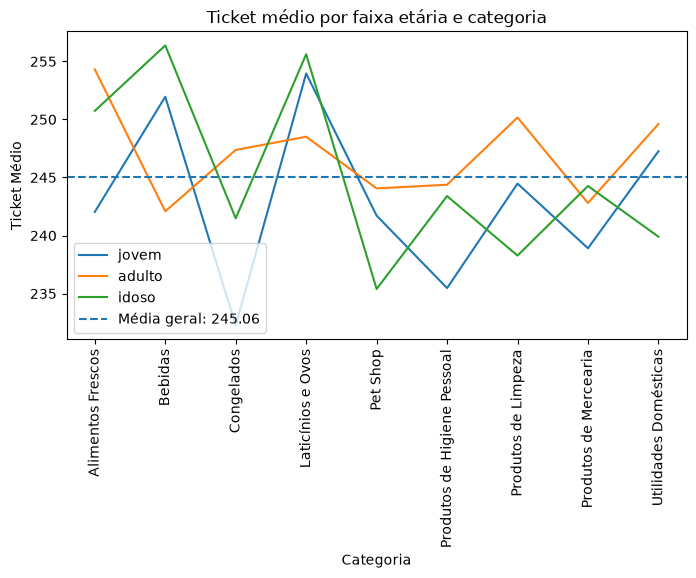

In [152]:
media = vendas_faixa_etaria.mean().mean()

ax = vendas_faixa_etaria.plot(
    figsize=(8, 4),
    kind='line',
    title='Ticket médio por faixa etária e categoria',
    ylabel='Ticket Médio',
    legend=True,
    xticks=range(len(vendas_faixa_etaria.index)),
    rot=90
)

ax.axhline(
    media,
    linestyle='--',
    label=f'Média geral: {media:.2f}'
)

ax.legend()

Analisando o gráfico em relaçao às categorias compradas por cada faixa etária podemos observar: <br>
O idoso se destaca sobre as compras de bebidas e laticínios, assim como o jovem <br>
O jovem se destaca na categoria de alimentos frescos, em produtos de limpeza e em utilidades domésticas.


## 9. Qual a relação entre a idade dos clientes e o valor total das compras?

## 10. Comparando a semana da "Black Friday"com a do Natal, qual semana a empresa teve melhores desempenhos em relação à média de vendas?

In [158]:
vendas_black_semana['Total_Venda'].mean()

np.float64(219.0511939393939)

In [ ]:
vendas_natal = vendas[(vendas['Data'] < '2023-12-25') & (vendas['Data'] > '2023-12-18')]

In [160]:
print(f'Média de vendas durante a semana do Natal: {vendas_natal["Total_Venda"].mean():.2f}')
print(f'Média de vendas durante a semana da Black Friday: {vendas_black_semana["Total_Venda"].mean():.2f}')

Média de vendas durante a semana do Natal: 225.27
Média de vendas durante a semana da Black Friday: 219.05


Em relação à média geral, a semana do Natal se saiu melhor que a semana da Black Friday. <br>
Vamos verificar se esse cenário muda em alguma categoria específica.

In [171]:
print("Média de vendas por categoria durante a semana da Black Friday")
print()
print(vendas_black.groupby('Categoria')['Total_Venda'].mean())
print()
print("Média de vendas por categoria durante a semana do Natal")
print()
print(vendas_natal.groupby('Categoria')['Total_Venda'].mean())

Média de vendas por categoria durante a semana da Black Friday

Categoria
Alimentos Frescos             244.71
Bebidas                       208.79
Congelados                     92.24
Laticínios e Ovos             112.22
Pet Shop                      104.53
Produtos de Higiene Pessoal   262.39
Produtos de Limpeza           139.84
Produtos de Mercearia         102.07
Utilidades Domésticas         229.68
Name: Total_Venda, dtype: float64

Média de vendas por categoria durante a semana do Natal

Categoria
Alimentos Frescos             223.65
Bebidas                       164.43
Congelados                    220.68
Laticínios e Ovos             200.12
Pet Shop                      268.16
Produtos de Higiene Pessoal   269.05
Produtos de Limpeza           270.57
Produtos de Mercearia         207.10
Utilidades Domésticas         206.93
Name: Total_Venda, dtype: float64


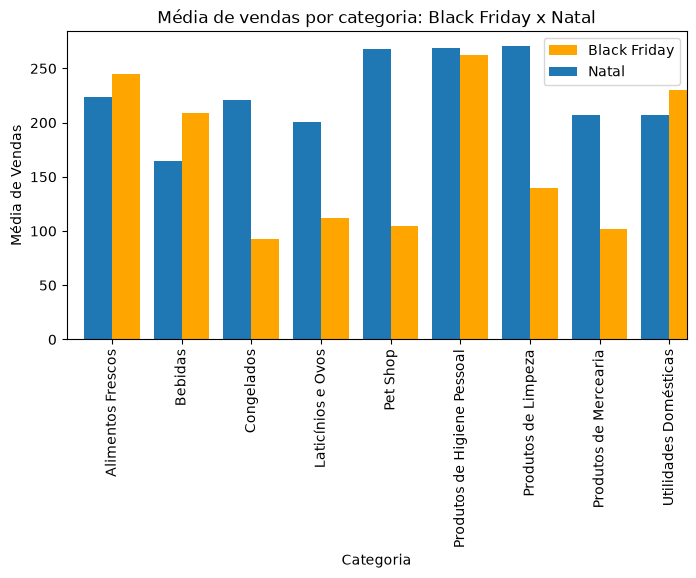

In [178]:
vendas_black_categoria = vendas_black.groupby('Categoria')['Total_Venda'].mean()
vendas_natal_categoria = vendas_natal.groupby('Categoria')['Total_Venda'].mean()

ax = vendas_black_categoria.plot(
    figsize=(8, 4),
    kind='bar',
    title='Média de vendas por categoria: Black Friday x Natal',
    ylabel='Média de Vendas',
    xlabel='Categoria',
    grid=True,
    position=0,
    width=0.4,
    color='orange'
)

vendas_natal_categoria.plot(
    ax=ax,
    kind='bar',
    position=1,
    width=0.4
)

ax.legend(['Black Friday', 'Natal'])

Através da análise do gráfico, podemos ver que a Black Friday se destacou somente em relação à Alimentos Frescos, Bebidas e Utilidades Domésticas